This question involves the use of multiple linear regression on the
Auto data set.


(a) Produce a scatterplot matrix which includes all of the variables
in the data set.

(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method.

(c) Use the sm.OLS() function to perform a multiple linear regression
with mpg as the response and all other variables except name as
the predictors. Use the summarize() function to print the results.
Comment on the output. For instance:

i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to
answer this question.

ii. Which predictors appear to have a statistically signifcant
relationship to the response?

iii. What does the coefcient for the year variable suggest?


(d) Produce some of diagnostic plots of the linear regression ft as
described in the lab. Comment on any problems you see with the
ft. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically signifcant?

(f) Try a few diferent transformations of the variables, such as
log(X),√X, X2. Comment on your findings.

In [47]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.anova import anova_lm
from ISLP.models import summarize, poly
from ISLP.models import ModelSpec as MS
from ISLP import load_data


In [30]:
df = pd.read_csv("Auto.csv")

In [31]:
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


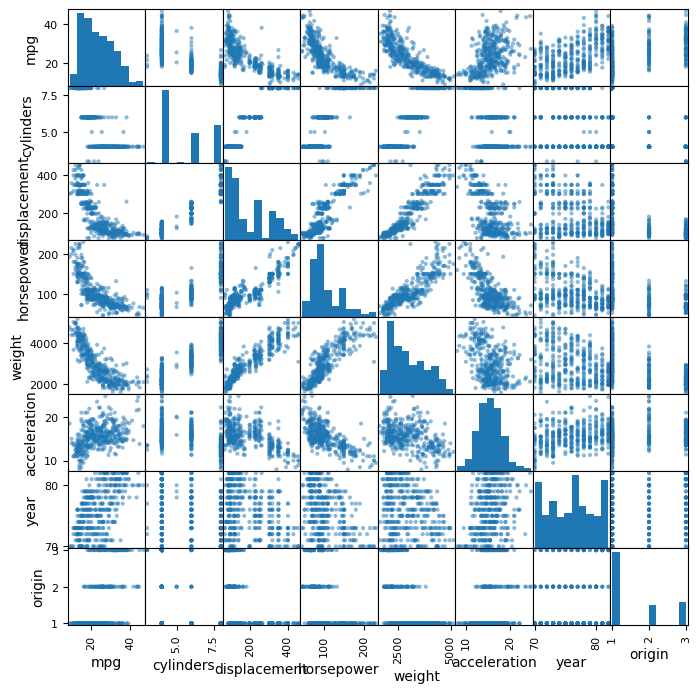

In [13]:




#a)

pd.plotting.scatter_matrix(df, figsize=(8,8))
plt.show()

In [32]:
df.iloc[:,0:8].corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


(c) Use the sm.OLS() function to perform a multiple linear regression
with mpg as the response and all other variables except name as
the predictors. Use the summarize() function to print the results.
Comment on the output. For instance:

i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to
answer this question.

ii. Which predictors appear to have a statistically signifcant
relationship to the response?

iii. What does the coefcient for the year variable suggest?


In [38]:
X = df.iloc[:,1:8]
Y = df["mpg"]

droplist = X[X.isin(["?"]).any(axis=1)].index
X= X.drop(droplist)
Y= Y.drop(droplist)

print(len(X), len(Y))

392 392


In [48]:
mod = smf.ols("mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin", data=df)
res = mod.fit()

print(res.summary())

print(res.params)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sat, 18 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        22:13:27   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.644     -3.707   

In [49]:
anova_res = anova_lm(res)
anova_res

,df,sum_sq,mean_sq,F,PR(>F)
cylinders,1.0,14403.083079,14403.083079,1300.683788,2.319511e-125
displacement,1.0,1073.344025,1073.344025,96.929329,1.530906e-20
horsepower,1.0,403.408069,403.408069,36.430140,3.731128e-09
weight,1.0,975.724953,975.724953,88.113748,5.544461e-19
acceleration,1.0,0.966071,0.966071,0.087242,7.678728e-01
year,1.0,2419.120249,2419.120249,218.460900,1.875281e-39
origin,1.0,291.134494,291.134494,26.291171,4.665681e-07
Residual,384.0,4252.212530,11.073470,NaN,NaN


i. The Pr(>F) is very small, so the majority of predictors might be correlated
ii. cylinders 
iii. positive linear correlation (75%)


(d) Produce some of diagnostic plots of the linear regression ft as
described in the lab. Comment on any problems you see with the
ft. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?


Text(0, 0.5, 'Residuals')

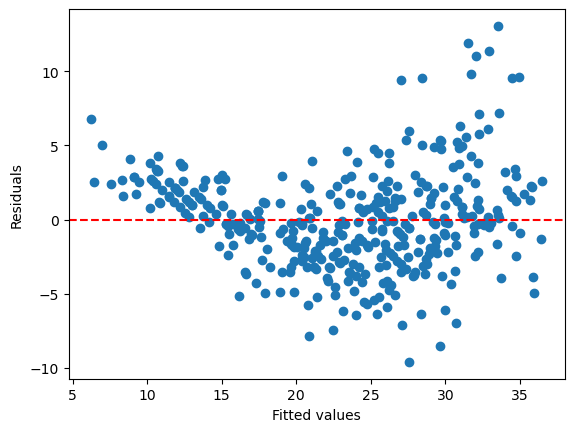

In [50]:
fitted_val = res.fittedvalues # to wartosc predykcji
resid_vals = res.resid # to wartosc bledu, czyli roznicy wartosci realnej od przewidzianej

fig, ax = plt.subplots()

ax.scatter(fitted_val, resid_vals)
ax.axhline(0,color="red", linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")

At first with low X args the error suggests some linear tendency, but later the trend seems to reverse so it's definetely not linear

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically signifcant?

In [59]:
model = smf.ols("mpg ~ horsepower * weight * acceleration ", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     170.8
Date:                Sat, 18 Oct 2025   Prob (F-statistic):          9.61e-114
Time:                        22:27:47   Log-Likelihood:                -1084.0
No. Observations:                 392   AIC:                             2184.
Df Residuals:                     384   BIC:                             2216.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

(f) Try a few diferent transformations of the variables, such as
log(X),√X, X2. Comment on your findings.

In [1]:
d = df

d["log_hp"] = np.log(df["horsepower"].astype(float))
d["sqrt_hp"] = np.sqrt(df["horsepower"].astype(float))
d["hp2"] = df["horsepower"].astype(float) ** 2

m1= smf.ols("mpg ~ horsepower", data=d).fit()

m1.summary()

NameError: name 'df' is not defined

In [65]:
m2= smf.ols("mpg ~ log_hp", data=d).fit()
print(m2.summary())

m3 = smf.ols("mpg ~ sqrt_hp", data=d).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     401.7
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           6.23e-62
Time:                        22:33:30   Log-Likelihood:                -1222.4
No. Observations:                 392   AIC:                             2449.
Df Residuals:                     390   BIC:                             2457.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.4658      0.447     68.219      0.0